In [1]:
import dilutionUtils as dil

In [3]:
files, injection, calibration = dil.load_config("./output/20250724_trial1_solution_injection_config.ini")

In [6]:
injection_data = dil.get_file_paths(files['data_folder'],files['search_string'])
injection_data

['./output/20250724_162611_840058.csv']

In [7]:
trial_data = dil.extract_fields(dil.read_csv(injection_data[0]))
cal_data = dil.extract_fields(dil.read_csv(files['calibration_file']))

In [8]:
#Vadd - this variable declaration is unecessary. Just put the cal_data in the function signature
RC_ss = dil.secondary_solution_RC(injection_solution=int(calibration['volume_injection_solution sample']),Vo=int(calibration['initial_volume_secondary']))
RC = dil.calibration_RC(RC_sec=RC_ss, additions_of_injection=cal_data['Additions_of_secondary_ml'],Vc=int(cal_data['Calibration_volume_ml'][0]))

In [9]:
slope_k = dil.calculate_k(RC_values=RC,EC_values=cal_data['Conductivity'])
print(f"{RC_ss}\n{RC}\n{slope_k}")

0.009900990099009901
[0.0, 3.2992302895734428e-06, 6.596262557634844e-06, 9.891099000009891e-06, 1.31837418096004e-05, 1.6474193176389187e-05, 1.9762455287444913e-05, 2.3048530326926942e-05, 2.6332420476090162e-05, 2.961412791328983e-05, 3.2893654813986384e-05, 3.617100335075022e-05, 3.944617569326654e-05, 4.27191740083401e-05]
1.613871326344545e-06


In [24]:
# get the time variables background, injection, total
bg_sec = dil.time_diff_sec(start=injection['bg_start'],end=injection['bg_end'])
trial_sec = dil.time_diff_sec(start=injection['bg_end'],end=injection['trial_end'])
total_sec = dil.time_diff_sec(start=injection['bg_start'],end=injection['record_end'])


In [25]:
total_sec

703

In [26]:
bg_value = dil.get_background_ec(start_time=0, end_time=bg_sec,ec_data=trial_data['Actual Conductivity (µS/cm)'][:bg_sec])

In [11]:
import numpy as np

In [27]:
cumm_sec = np.arange(0,704,1,)
diff_sec = np.diff(cumm_sec)


In [ ]:
# needs to be fixed! this funcution requires a list of datetime objects but the arguement is a list of time strings
diff, cumm = dil.compute_time_differences_in_seconds(trial_data['Date Time'])

In [28]:
Q = dil.calculate_Q(
    ec_bg=bg_value,
    ec_data=trial_data['Actual Conductivity (µS/cm)'],
    slope=slope_k,
    time_step=diff_sec,
    injection_volume=injection['injection_volume']
)

ValueError: operands could not be broadcast together with shapes (704,) (703,) 

In [ ]:
Q

KeyError: slice(169, 417, None)

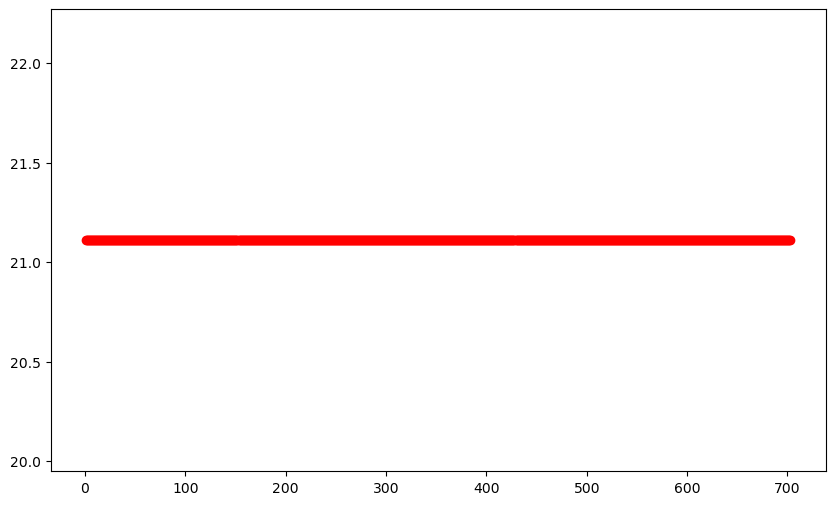

In [ ]:
dil.plot_injection(data=trial_data, time_elapsed=cumm_sec, bg_sec=169,trial_sec=trial_sec,total_diff=diff_sec,show_background=False)